# Variational Inference for Gaussian Mixtures

Mean-field VI maximizes an ELBO
$$
\mathcal{L}(q)=\mathbb{E}_q[\log p(X,Z,\Theta)]-\mathbb{E}_q[\log q(Z,\Theta)].
$$
For didactic clarity we run soft-EM style coordinate updates and monitor the objective.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/variational-inference-gmm/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/variational-inference-gmm") if Path("python/variational-inference-gmm").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Variational Inference for Gaussian Mixtures**, with equations and plots designed to expose both the model and the numerical behavior.


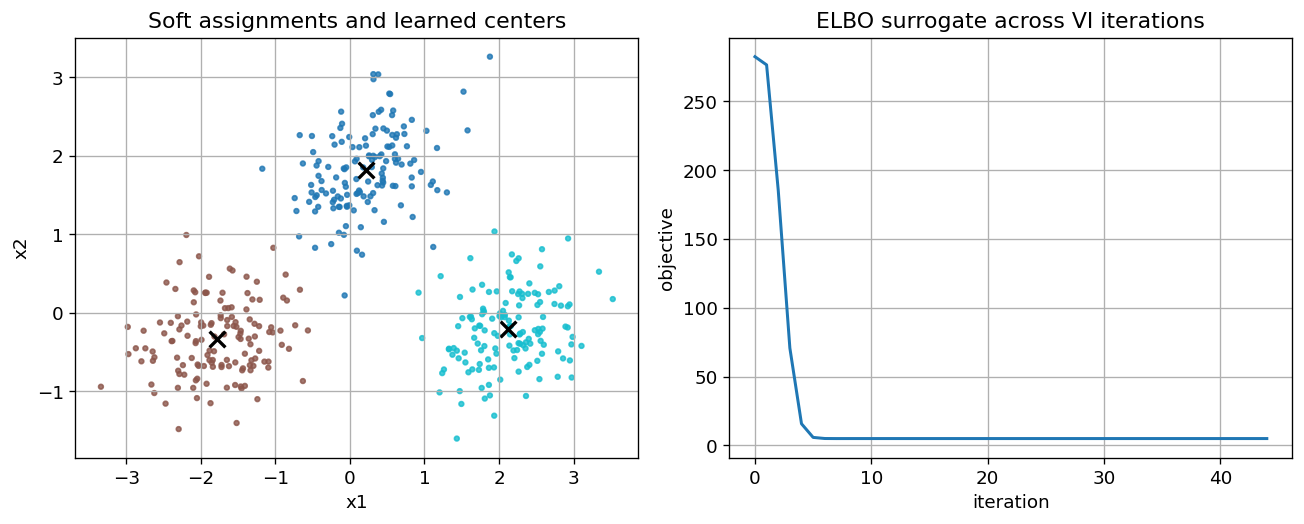

In [2]:
n = 420
mu_true = np.array([[-1.8, -0.4], [0.2, 1.8], [2.1, -0.2]])
cov = np.array([[0.28, 0.06], [0.06, 0.24]])
X = np.vstack([rng.multivariate_normal(m, cov, size=n//3) for m in mu_true])

K = 3
N = len(X)
mu = X[rng.choice(N, size=K, replace=False)].copy()
pi = np.ones(K) / K
sigma2 = np.ones(K) * 0.45

elbo_like = []
for _ in range(45):
    # E-step responsibilities
    log_r = np.zeros((N, K))
    for k in range(K):
        d2 = np.sum((X - mu[k])**2, axis=1)
        log_r[:, k] = np.log(pi[k] + 1e-16) - 0.5*(2*np.log(2*np.pi*sigma2[k]) + d2/sigma2[k])
    log_r -= log_r.max(axis=1, keepdims=True)
    r = np.exp(log_r)
    r /= r.sum(axis=1, keepdims=True)

    Nk = r.sum(axis=0) + 1e-12
    pi = Nk / N
    mu = (r.T @ X) / Nk[:, None]
    for k in range(K):
        d2 = np.sum((X - mu[k])**2, axis=1)
        sigma2[k] = (r[:, k] @ d2) / (2*Nk[k]) + 1e-6

    ll = np.sum(np.log(np.sum(np.exp(log_r), axis=1) + 1e-16) + log_r.max(axis=1))
    ent = -np.sum(r * np.log(r + 1e-16))
    elbo_like.append(ll + ent)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c=np.argmax(r, axis=1), s=8, cmap="tab10", alpha=0.8)
axes[0].scatter(mu[:, 0], mu[:, 1], c="k", s=90, marker="x", lw=2)
axes[0].set_title("Soft assignments and learned centers")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].plot(elbo_like, lw=1.8)
axes[1].set_title("ELBO surrogate across VI iterations")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("objective")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- D. M. Blei, A. Kucukelbir, J. D. McAuliffe, "Variational Inference: A Review for Statisticians", JASA, 2017.
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006.
- M. I. Jordan et al., "An Introduction to Variational Methods for Graphical Models", Machine Learning, 1999.
